# Football Stats EDA

This notebook performs exploratory analysis on the exported football player statistics dataset. Each row represents a player summary and includes the exported metrics already generated by the project pipeline.

The goal is to understand the distribution of total distance, average speed, and ball possession across the players in the CSV.

## 1. Introduction

This dataset contains summary-level football statistics for each player after the video analysis pipeline exports its results. The notebook focuses only on the fields already available in `player_stats.csv`:

- `player_id`
- `team`
- `total_distance_m`
- `avg_speed_kmh`
- `ball_possession_frames`

The analysis below is intentionally simple and beginner-friendly, with a focus on understanding the exported stats before any deeper interpretation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'analysis' else notebook_dir
csv_path = project_root / 'output_videos' / 'player_stats.csv'

df = pd.read_csv(csv_path)

df.head()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (39, 5)
Columns: ['player_id', 'team', 'total_distance_m', 'avg_speed_kmh', 'ball_possession_frames']


## 2. Load Dataset

This section loads the CSV file, displays the first rows, and confirms the dataset shape and available columns.

In [2]:
# Display first few rows of the dataset
print('First few rows:')
df.head()

# Display dataset shape and column names
print(f'\nShape: {df.shape}')
print(f'Columns: {list(df.columns)}')

First few rows:

Shape: (39, 5)
Columns: ['player_id', 'team', 'total_distance_m', 'avg_speed_kmh', 'ball_possession_frames']


## 3. Data Validation

Before analyzing the metrics, it is important to validate the dataset and check for missing or unexpected values.

In [3]:
expected_columns = ['player_id', 'team', 'total_distance_m', 'avg_speed_kmh', 'ball_possession_frames']

missing_values = df.isnull().sum()
print('Missing values by column:')
print(missing_values)

print('\nData types:')
print(df.dtypes)

print(f'\nUnique players: {df["player_id"].nunique()}')
print(f'Unique teams: {df["team"].nunique()}')

missing_columns = [col for col in expected_columns if col not in df.columns]
if missing_columns:
    print(f'\nMissing expected columns: {missing_columns}')
else:
    print('\nAll expected columns are present.')

Missing values by column:
player_id                 0
team                      0
total_distance_m          0
avg_speed_kmh             0
ball_possession_frames    0
dtype: int64

Data types:
player_id                   int64
team                        int64
total_distance_m          float64
avg_speed_kmh             float64
ball_possession_frames      int64
dtype: object

Unique players: 39
Unique teams: 2

All expected columns are present.


## 4. Basic Statistics

The summary below gives the overall ranges and variability for the key numerical features in the dataset.

In [4]:
numeric_cols = ['total_distance_m', 'avg_speed_kmh', 'ball_possession_frames']
summary = df[numeric_cols].describe().T
summary

# Print a compact summary for quick inspection
print(summary.round(2).to_string())

                        count   mean    std  min  25%   50%    75%     max
total_distance_m         39.0  23.32  28.03  0.0  0.0  2.25  53.16   76.27
avg_speed_kmh            39.0   4.47   4.46  0.0  0.0  6.46   7.89   12.98
ball_possession_frames   39.0  13.28  27.29  0.0  0.0  2.00  13.00  146.00


## 5. Team Analysis

This section compares the two teams based on average total distance, average speed, and total possession frames.

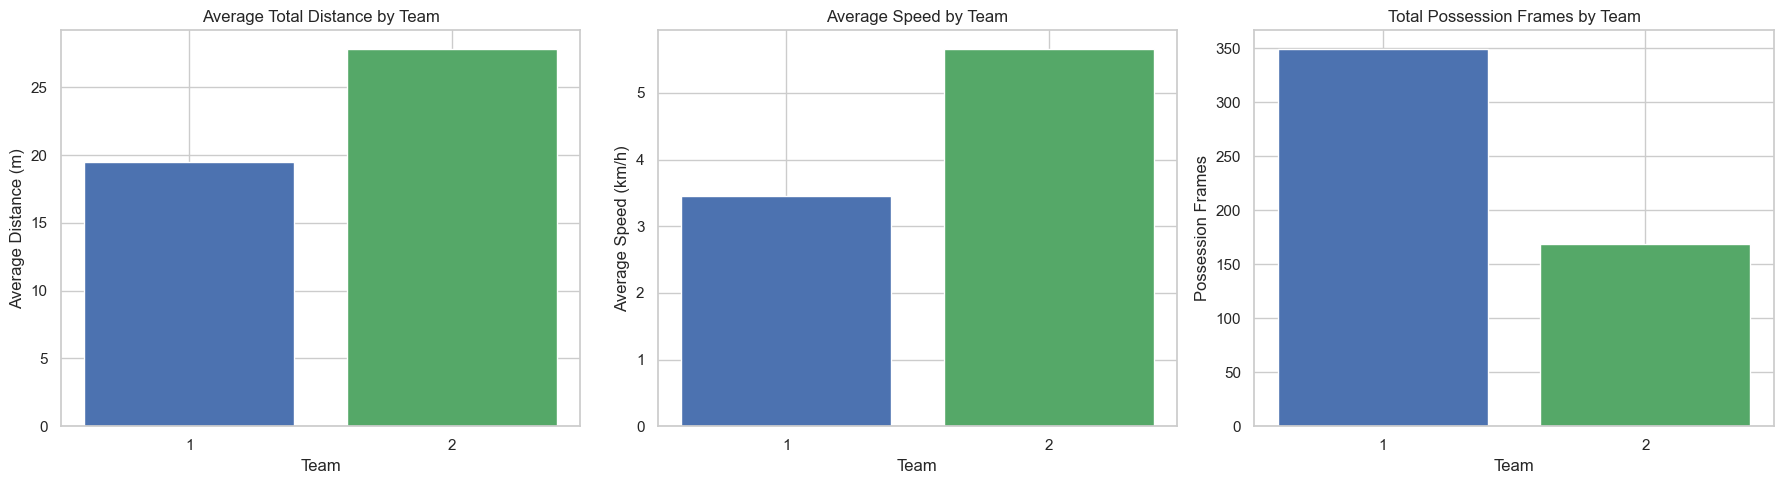

In [5]:
team_summary = (
    df.groupby('team')
      .agg(
          avg_total_distance_m=('total_distance_m', 'mean'),
          avg_speed_kmh=('avg_speed_kmh', 'mean'),
          total_possession_frames=('ball_possession_frames', 'sum'),
          players=('player_id', 'count')
      )
      .reset_index()
)
team_summary

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(team_summary['team'].astype(str), team_summary['avg_total_distance_m'], color=['#4C72B0', '#55A868'])
axes[0].set_title('Average Total Distance by Team')
axes[0].set_xlabel('Team')
axes[0].set_ylabel('Average Distance (m)')

axes[1].bar(team_summary['team'].astype(str), team_summary['avg_speed_kmh'], color=['#4C72B0', '#55A868'])
axes[1].set_title('Average Speed by Team')
axes[1].set_xlabel('Team')
axes[1].set_ylabel('Average Speed (km/h)')

axes[2].bar(team_summary['team'].astype(str), team_summary['total_possession_frames'], color=['#4C72B0', '#55A868'])
axes[2].set_title('Total Possession Frames by Team')
axes[2].set_xlabel('Team')
axes[2].set_ylabel('Possession Frames')

plt.tight_layout()
plt.show()

## 6. Player Analysis

The next plots highlight the top 5 players by total distance and by possession frames, keeping the scope limited to the top 5 only.

Top 5 players by total distance:
 player_id  team  total_distance_m  avg_speed_kmh  ball_possession_frames
         3     1             76.27           8.77                      36
         5     2             71.79           8.29                      17
        12     2             70.39           8.73                      25
         6     2             64.88           7.48                      45
        14     1             64.70           7.44                       0

Top 5 players by possession frames:
 player_id  team  total_distance_m  avg_speed_kmh  ball_possession_frames
        91     1              9.84           6.55                     146
         7     1             52.88           6.99                      72
         6     2             64.88           7.48                      45
        11     2             58.91           6.93                      45
         3     1             76.27           8.77                      36


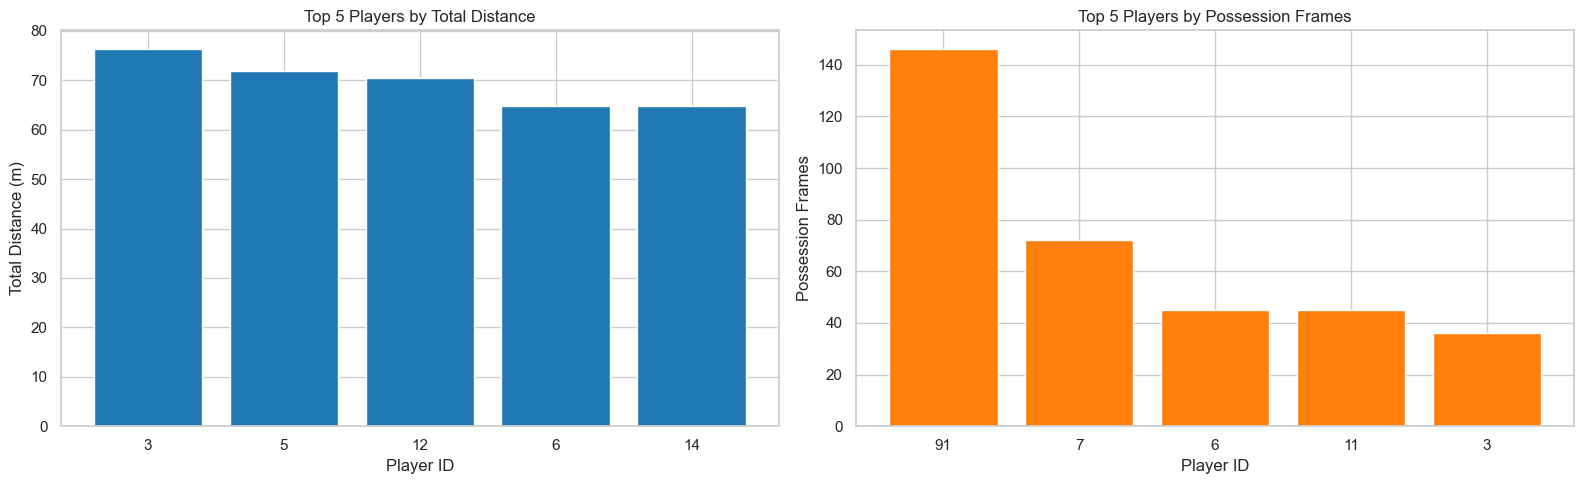

In [6]:
top5_distance = df.sort_values('total_distance_m', ascending=False).head(5)
top5_possession = df.sort_values('ball_possession_frames', ascending=False).head(5)

print('Top 5 players by total distance:')
print(top5_distance[['player_id', 'team', 'total_distance_m', 'avg_speed_kmh', 'ball_possession_frames']].to_string(index=False))
print('\nTop 5 players by possession frames:')
print(top5_possession[['player_id', 'team', 'total_distance_m', 'avg_speed_kmh', 'ball_possession_frames']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(top5_distance['player_id'].astype(str), top5_distance['total_distance_m'], color='#1f77b4')
axes[0].set_title('Top 5 Players by Total Distance')
axes[0].set_xlabel('Player ID')
axes[0].set_ylabel('Total Distance (m)')

axes[1].bar(top5_possession['player_id'].astype(str), top5_possession['ball_possession_frames'], color='#ff7f0e')
axes[1].set_title('Top 5 Players by Possession Frames')
axes[1].set_xlabel('Player ID')
axes[1].set_ylabel('Possession Frames')

plt.tight_layout()
plt.show()

## 7. Distribution Analysis

This section looks at how the main performance metrics are distributed across all players.

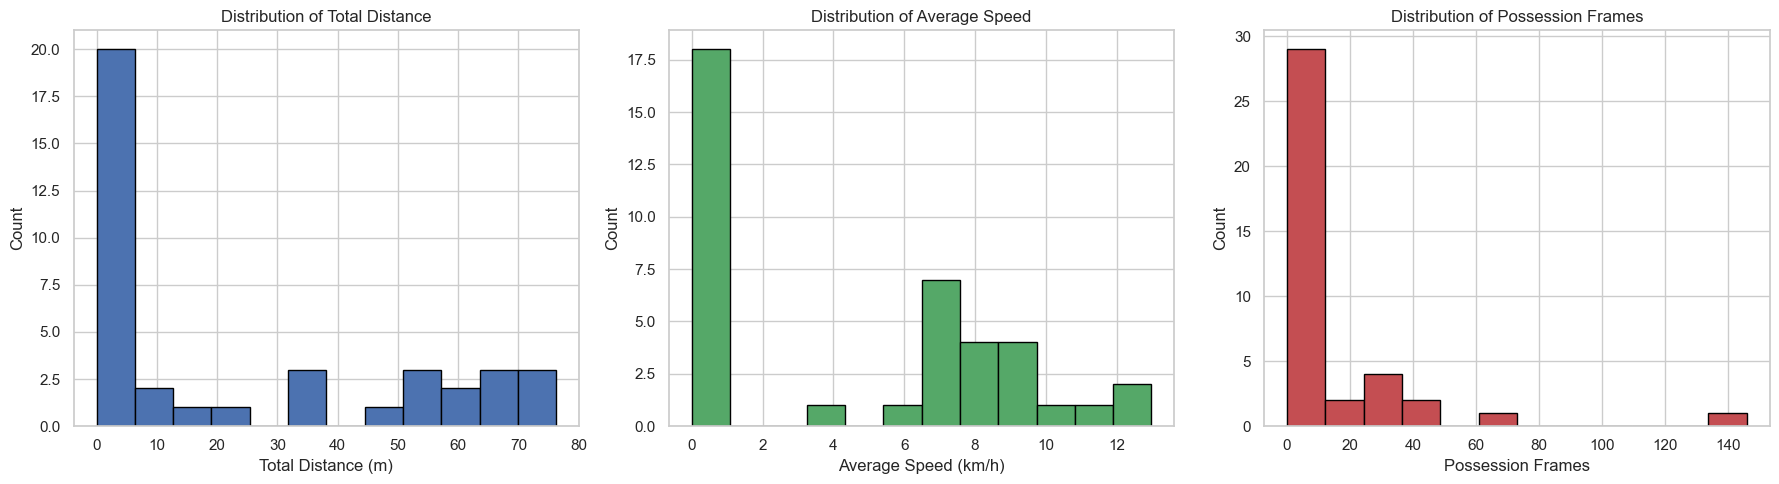

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['total_distance_m'], bins=12, color='#4C72B0', edgecolor='black')
axes[0].set_title('Distribution of Total Distance')
axes[0].set_xlabel('Total Distance (m)')
axes[0].set_ylabel('Count')

axes[1].hist(df['avg_speed_kmh'], bins=12, color='#55A868', edgecolor='black')
axes[1].set_title('Distribution of Average Speed')
axes[1].set_xlabel('Average Speed (km/h)')
axes[1].set_ylabel('Count')

axes[2].hist(df['ball_possession_frames'], bins=12, color='#C44E52', edgecolor='black')
axes[2].set_title('Distribution of Possession Frames')
axes[2].set_xlabel('Possession Frames')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 8. Relationship Analysis

The scatter plot below compares total distance and average speed to see whether there is an obvious relationship between the two variables.

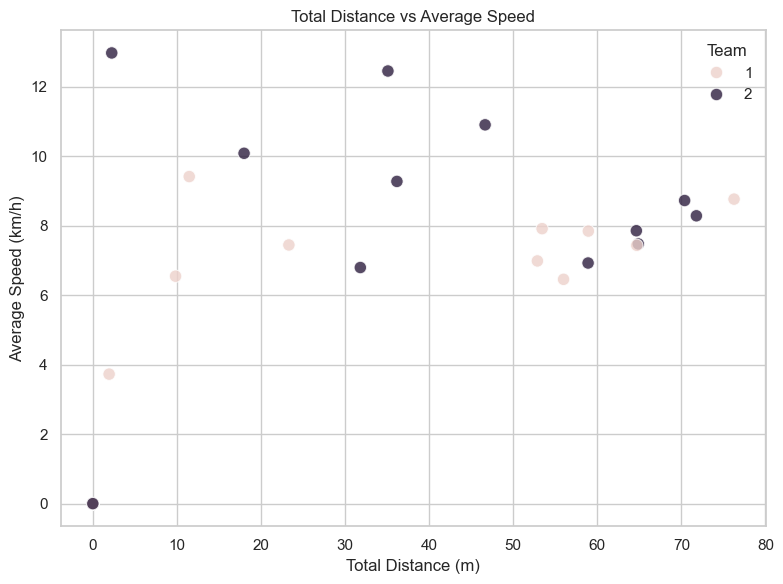

Correlation between total distance and average speed: 0.710


In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='total_distance_m', y='avg_speed_kmh', hue='team', s=80, alpha=0.8)
plt.title('Total Distance vs Average Speed')
plt.xlabel('Total Distance (m)')
plt.ylabel('Average Speed (km/h)')
plt.legend(title='Team')
plt.tight_layout()
plt.show()

print(f"Correlation between total distance and average speed: {df[['total_distance_m', 'avg_speed_kmh']].corr().iloc[0, 1]:.3f}")

## 9. Key Findings

Based on the actual dataset:

- Team 2 has a higher average total distance per player than Team 1, and also a higher average speed.
- The strongest possession value is player 91 with 146 possession frames, which is far above the next highest values in the dataset.
- The dataset includes a wide range of player activity levels, with some players recording very low distance and possession values while others are much higher.

This notebook is limited to the exported features already available in the CSV and does not introduce any additional metrics beyond those values.